In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
DATA_PATH = Path("../data/raw/smart_energy.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,timestamp,household_id,consumption_kwh,solar_generation_kwh,temperature_c,humidity_percent
0,2026-01-01 00:00:00,H001,0.672,0.0,27.75,77.82
1,2026-01-01 01:00:00,H001,0.444,0.0,26.73,72.80
2,2026-01-01 02:00:00,H001,0.852,0.0,28.98,67.44
3,2026-01-01 03:00:00,H001,1.151,0.0,30.61,68.13
4,2026-01-01 04:00:00,H001,1.213,0.0,30.93,63.76


In [5]:
DATA_PATH = Path("../data/raw/smart_energy.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,timestamp,household_id,consumption_kwh,solar_generation_kwh,temperature_c,humidity_percent
0,2026-01-01 00:00:00,H001,0.672,0.0,27.75,77.82
1,2026-01-01 01:00:00,H001,0.444,0.0,26.73,72.80
2,2026-01-01 02:00:00,H001,0.852,0.0,28.98,67.44
3,2026-01-01 03:00:00,H001,1.151,0.0,30.61,68.13
4,2026-01-01 04:00:00,H001,1.213,0.0,30.93,63.76


In [7]:
df.shape

(43200, 6)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             43200 non-null  str    
 1   household_id          43200 non-null  str    
 2   consumption_kwh       43200 non-null  float64
 3   solar_generation_kwh  43200 non-null  float64
 4   temperature_c         43200 non-null  float64
 5   humidity_percent      43200 non-null  float64
dtypes: float64(4), str(2)
memory usage: 2.0 MB


In [9]:
df.describe()

,consumption_kwh,solar_generation_kwh,temperature_c,humidity_percent
count,43200.000000,43200.000000,43200.000000,43200.000000
mean,1.611369,1.270951,27.000906,74.982978
std,1.146711,1.547912,3.000339,7.703837
min,0.100000,0.000000,19.110000,54.580000
25%,0.749000,0.000000,24.330000,68.340000
50%,1.065000,0.001000,26.990000,75.000000
75%,2.521000,2.824000,29.670000,81.620000
max,4.959000,4.703000,34.090000,94.860000


In [10]:
df.isnull().sum()

timestamp               0
household_id            0
consumption_kwh         0
solar_generation_kwh    0
temperature_c           0
humidity_percent        0
dtype: int64

In [11]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

In [12]:
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = (
    df["timestamp"].dt.dayofweek
)

df["month"] = (
    df["timestamp"].dt.month
)

In [13]:
hourly_consumption = (
    df.groupby("hour")["consumption_kwh"]
    .mean()
)

hourly_consumption

hour
0     0.823647
1     0.818113
2     0.816375
3     0.826499
4     0.827766
5     0.814999
6     2.355338
7     2.362079
8     2.354227
9     2.363474
10    0.828018
11    0.808747
12    0.831464
13    0.820682
14    0.820692
15    0.823193
16    0.821984
17    0.820507
18    3.389067
19    3.372573
20    3.384439
21    3.383582
22    3.387606
23    0.817794
Name: consumption_kwh, dtype: float64

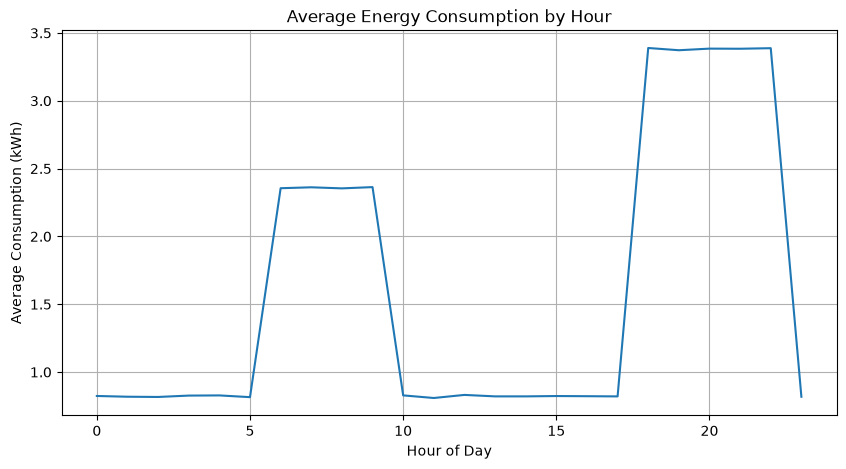

In [14]:
plt.figure(figsize=(10, 5))

hourly_consumption.plot()

plt.title(
    "Average Energy Consumption by Hour"
)

plt.xlabel("Hour of Day")

plt.ylabel(
    "Average Consumption (kWh)"
)

plt.grid()

plt.show()

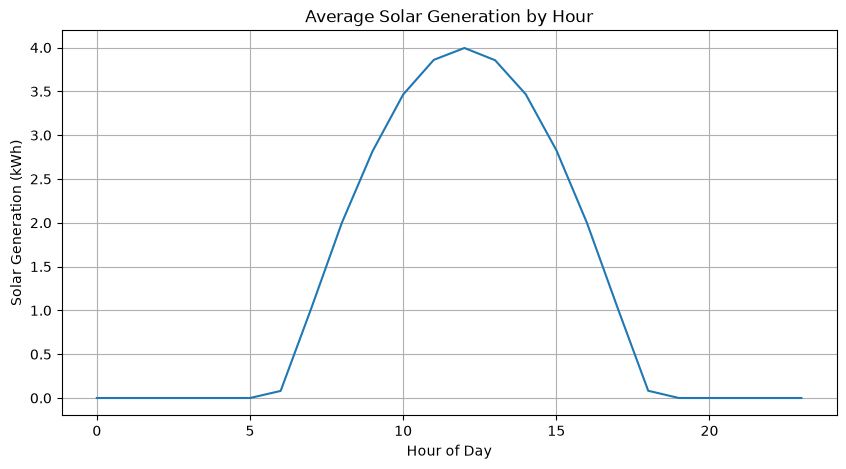

In [15]:
hourly_solar = (
    df.groupby("hour")
    ["solar_generation_kwh"]
    .mean()
)

plt.figure(figsize=(10, 5))

hourly_solar.plot()

plt.title(
    "Average Solar Generation by Hour"
)

plt.xlabel("Hour of Day")

plt.ylabel(
    "Solar Generation (kWh)"
)

plt.grid()

plt.show()